# Vision Transformer from scratch


## Load the dataset and resize them

In [ ]:
# import torch
# from torchvision.datasets import OxfordIIITPet
# import matplotlib.pyplot as plt
# from random import random
# from torchvision.transforms import Resize, ToTensor
# from torchvision.transforms.functional import to_pil_image

# to_tensor = [Resize((144, 144)), ToTensor()]

# class Compose(object):
#     def __init__(self, transforms):
#         self.transforms = transforms

#     def __call__(self, image, target):
#         for t in self.transforms:
#             image = t(image)
#         return image, target

# def show_images(images, num_samples=40, cols=8):
#     """ Plots some samples from the dataset """
#     plt.figure(figsize=(15,15))
#     idx = int(len(dataset) / num_samples)
   
#     for i, img in enumerate(images):
#         if i % idx == 0:
#             plt.subplot(int(num_samples/cols) + 1, cols, int(i/idx) + 1)
#             plt.imshow(to_pil_image(img[0]))

# # 200 images for each pet
# dataset = OxfordIIITPet(root=".", download=True, transforms=Compose(to_tensor)) #(num, 3, 144, 144)
# show_images(dataset)


## CIFAR-100


In [ ]:
import torch
from torchvision.datasets import CIFAR100
import matplotlib.pyplot as plt
from torchvision.transforms import Resize, ToTensor

# Resize to 64x64 to save massive compute compared to 144x144
to_tensor = [Resize((64, 64)), ToTensor()]

class Compose(object):
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, image): # Remove 'target' here
        for t in self.transforms:
            image = t(image)
        return image # Return only the transformed image

# Download CIFAR-100
# Notice we split train and test properly using the built-in PyTorch flag
train_dataset = CIFAR100(root=".", train=True, download=True, transform=Compose(to_tensor))
test_dataset = CIFAR100(root=".", train=False, download=True, transform=Compose(to_tensor))
print(f"Training images: {len(train_dataset)}")
print(f"Testing images: {len(test_dataset)}")

In [ ]:
import torch.nn.functional as F

## Patchify the image, create embedding for each batch and Positional Encoding

In [ ]:
import torch.nn as nn
from einops.layers.torch import Rearrange
import math
class PatchEmbedding(nn.Module): 
    def __init__(self, in_channels = 3, patch_size = 16, d_model = 128): 
        super().__init__()
        self.patch_size = patch_size
        #(b,c,h,w)->(b,N,p^2*c) where N is the number of patches
        self.patch_embedding =nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_size, p2 = patch_size),
            nn.Linear(patch_size*patch_size*in_channels, d_model)
        )
    def forward(self,x):
        return self.patch_embedding(x)
class PositionalEncoding(nn.Module): 
    def __init__(self, num_patches : int,d_model: int = 128, drop_out :float = 0.1):
        super().__init__()
        self.d_model =d_model
        self.num_patches = num_patches
        self.drop_out =  nn.Dropout(drop_out)
        #(num_patches, d_model)
        pe = torch.zeros(num_patches, d_model)
        position = torch.arange(0, num_patches,dtype=torch.float).unsqueeze(1) #(num_patches,1)
        div_term = torch.exp(
            torch.arange(0,d_model,2)*(-math.log(10000.0)/d_model)
        )
        pe[:,0::2]  = torch.sin(position*div_term)
        pe[:,1::2]  = torch.cos(position*div_term)
        pe =  pe.unsqueeze(0)
        self.register_buffer('pe',pe)
    def forward(self,x): 
        x=  x + self.pe[:,:x.shape[1],:].requires_grad_(False)
        return self.drop_out(x)
# Run a quick test
sample_datapoint = torch.unsqueeze(train_dataset[0][0], 0)
print("Initial shape: ", sample_datapoint.shape)
embedding = PatchEmbedding()(sample_datapoint)

## Building components



In [ ]:
class LayerNormalization(nn.Module):
    def __init__(self, feature_size:int =128, eps:float = 1e-6 ):
        super().__init__()
        self.eps = eps
        self.alpha  = nn.Parameter(torch.ones(feature_size))
        self.beta = nn.Parameter(torch.zeros(feature_size))
    def forward(self,x): 
        #(batch, patch, )
        mean =  x.mean(dim = -1, keepdim = True)
        var =    x.var(dim = -1, keepdim =True)    
        return self.alpha*(x-mean)/torch.sqrt(var+self.eps) + self.beta

### Vanilla Attention

In [ ]:

class MultiheadAttention(nn.Module):    
    def __init__(self, d_model:int, head:int = 8, drop_out: float =0.1): 
        super().__init__()
        self.head= head
        self.d_model = d_model
        self.w_k  = nn.Linear(d_model, d_model)
        self.w_q  = nn.Linear(d_model, d_model)
        self.w_v   = nn.Linear(d_model, d_model)
        self.w_o  = nn.Linear(d_model, d_model)
        self.drop_out = nn.Dropout(drop_out)

    def forward(self, key, value, query): 
        q =   self.w_q(query)
        v = self.w_v(value)
        k =self.w_k(key) # (b,p,w*h*c)->(b,p,h,w*h*c/h_)->(b,h,p,...)
        d_k =self.d_model//self.head
        q= q.view(q.shape[0],q.shape[1],self.head,-1).transpose(2,1)
        v= v.view(v.shape[0],v.shape[1],self.head,-1).transpose(2,1)
        k= k.view(k.shape[0],k.shape[1],self.head,-1).transpose(2,1)
        x, self.attention_score =  self.Softmax_attention(k,v,q,d_k,self.drop_out)
        x = x.transpose(1,2).contiguous().view(x.shape[0],-1, self.d_model)
        return self.w_o(x)
    @staticmethod
    def Softmax_attention(key, value, query, d_k: int, drop_out: nn.Dropout): 
        #(b,h,p,...)
        attention_score = query@key.transpose(-2,-1)/math.sqrt(d_k)
        attention_score = torch.softmax(attention_score, dim=-1) #(b,h,p,p), with every querry apply the softmax to the q@k
        if drop_out is not None: 
            attention_score = drop_out(attention_score)
        return (attention_score)@value, attention_score #(b,h,p,...) \
embedding = MultiheadAttention(128,8,0.1)(embedding,embedding,embedding)
print(embedding)

### Linear Attention

In [ ]:
class LinearMultiheadAttention(nn.Module):    
    def __init__(self, d_model:int, head:int = 8, drop_out: float =0.1): 
        super().__init__()
        self.head= head
        self.d_model = d_model
        self.w_k  = nn.Linear(d_model, d_model)
        self.w_q  = nn.Linear(d_model, d_model)
        self.w_v   = nn.Linear(d_model, d_model)
        self.w_o  = nn.Linear(d_model, d_model)
        self.linear_map =  nn.ELU()
        self.drop_out = nn.Dropout(drop_out)

    def forward(self, key, value, query): 
        q = self.linear_map(self.w_q(query)) +1.0
        v = self.w_v(value)
        k = self.linear_map(self.w_k(key)) + 1.0 # (b,p,w*h*c)->(b,p,h,w*h*c/h_)->(b,h,p,...)
        d_k =self.d_model//self.head
        q= q.view(q.shape[0],q.shape[1],self.head,-1).transpose(2,1)
        v= v.view(v.shape[0],v.shape[1],self.head,-1).transpose(2,1)
        k= k.view(k.shape[0],k.shape[1],self.head,-1).transpose(2,1)
        x=  self.Linear_attention(k,v,q,d_k,self.drop_out) #(b,h,p,d_k)
        x = x.transpose(1,2).contiguous().view(x.shape[0],-1, self.d_model)
        return self.w_o(x)
    @staticmethod
    def Linear_attention(key, value, query, d_k: int, drop_out: nn.Dropout, eps = 1e-6): 
        #(b,h,p,...)
        KV = key.transpose(-2,-1)@value #(b,h,d_k,p)@(b,h,p,d_k)-->*(b,h,d_k,d_k)
        n =  query@KV #(b,h,p,d_k)@(b,h,d_k,d_k)--> (b,h,p,d_k)
        div_term = query@(key.sum(dim =-2, keepdim = True).transpose(-2,-1))#(b,h,1,d_k)
        attention_score = n/(div_term+eps) #(b,h,p,d_k)
        if drop_out is not None: 
            attention_score = drop_out(attention_score)
        return attention_score

In [ ]:
class RALAMultiheadAttention(nn.Module):
    def __init__(self, d_model:int, head:int = 8, drop_out: float =0.1): 
        super().__init__()
        self.head= head
        self.d_model = d_model
        self.w_k  = nn.Linear(d_model, d_model)
        self.w_q  = nn.Linear(d_model, d_model)
        self.w_v   = nn.Linear(d_model, d_model)
        self.w_o_gate = nn.Linear(d_model, d_model)
        self.w_o_proj = nn.Linear(d_model, d_model)
        self.linear_map =  nn.ELU()
        self.drop_out = nn.Dropout(drop_out)

    def forward(self, key, value, query): 
        q = self.w_q(query)
        v = self.w_v(value)
        k = self.w_k(key)# (b,p,w*h*c)->(b,p,h,w*h*c/h_)->(b,h,p,...)
        o_gate = self.w_o_gate(query)
        d_k =self.d_model//self.head
        q= q.view(q.shape[0],q.shape[1],self.head,-1).transpose(2,1)
        v= v.view(v.shape[0],v.shape[1],self.head,-1).transpose(2,1)
        k= k.view(k.shape[0],k.shape[1],self.head,-1).transpose(2,1)
        x=  self.Linear_attention(k,v,q,d_k,self.drop_out) #(b,h,p,d_k)
        x = x.transpose(1,2).contiguous().view(x.shape[0],-1, self.d_model)
        x = x*torch.sigmoid(o_gate)
        return self.w_o_proj(x)
    @staticmethod
    def Linear_attention(key, value, query, d_k: int, drop_out: nn.Dropout, eps = 1e-6): 
        #(b,h,p,...)
        q_avg =  query.mean(dim =-2, keepdim = True)#*(b,h,1,d_k)@(b,h,d_k,n) (b,h,1,n)
        q =  F.elu(query)+1.0
        key = F.elu(key)+1.0
        N = query.shape[-2]
        scale= d_k**-0.5
        eff = (q_avg@key.transpose(-2,-1))*scale
        eff = torch.softmax(eff,dim =-1).transpose(-2,-1)
        key  = key *eff*N
        KV = key.transpose(-2,-1)@value #(b,h,d_k,p)@(b,h,p,d_k)-->*(b,h,d_k,d_k)
        n =  q@KV #(b,h,p,d_k)@(b,h,d_k,d_k)--> (b,h,p,d_k)
        div_term = q@(key.sum(dim =-2, keepdim = True).transpose(-2,-1))#(b,h,1,d_k)
        attention_score = n/(div_term+eps) #(b,h,p,d_k)
        if drop_out is not None: 
            attention_score = drop_out(attention_score)
        return attention_score

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int =  2048, drop_out:float = 0.1): 
        super().__init__()
        
        self.linear1  = nn.Linear(d_model, d_model*4)
        self.linear2 = nn.Linear(d_model*4, d_model)
        self.drop_out = nn.Dropout(drop_out)
    def forward(self, x): 
        return self.linear2(self.drop_out(torch.relu(self.linear1(x))))
class ResidualConnect(nn.Module):
    def __init__(self, feature_size: int, drop_out:float):
        super().__init__()
        self.drop_out = nn.Dropout(drop_out)
        self.norm = LayerNormalization(feature_size = feature_size)
    def forward(self, x, sublayer: nn.Module):
        return x + self.drop_out(sublayer(self.norm(x)))
    
print(embedding.shape)
embedding = FeedForward(128)(embedding)
embedding = ResidualConnect(128, 0.1)(embedding, lambda x : MultiheadAttention(128,8,0.1)(x,x,x))
print(embedding)

In [ ]:
class EncoderBlock(nn.Module): 
    def __init__(self, d_model:int, multihead_attention, ffw : FeedForward, drop_out:float =0.1): 
        super().__init__()
        self.d_model = d_model
        self.attention = multihead_attention
        self.ffw = ffw
        self.drop_out = drop_out
        self.residualConection = nn.ModuleList([ResidualConnect(self.d_model,drop_out)for i in range(2)])
    def forward(self,x):
        x=  self.residualConection[0](x,lambda x: self.attention(x,x,x))
        x=  self.residualConection[1](x,self.ffw)
        return x
class Encoder(nn.Module):
    def __init__(self, layers:nn.ModuleList,d_model:int = 128): 
            super().__init__()
            self.layers = layers

            self.norm = LayerNormalization(d_model)
    def forward(self,x):
        for layer in self.layers: 
             x = layer(x)
        return self.norm(x)



In [ ]:
from einops import repeat
class ViT(nn.Module):
    def __init__(self, d_model: int =128, in_channels:int = 3, patch_size: int =4, head: int =8, out_dim: int =100, drop_out:float =0.1, layers:int = 3, img_size = 64,attention_kind =0):
        super().__init__()
        self.d_model = d_model
        self.h = img_size
        self.w = img_size
        num_patches =  (img_size//patch_size)**2
        self.patch_embedding = PatchEmbedding(in_channels,patch_size,d_model)
        self.cls_token = nn.Parameter(torch.rand(1,1,d_model))
        self.pe = nn.Parameter(torch.randn(1,num_patches+1,d_model))
        encoder_blocks = []
        
        for i in range(layers):
           if not attention_kind :  
            attention = LinearMultiheadAttention(self.d_model, head, drop_out)
           elif attention_kind ==1:
            attention = MultiheadAttention(self.d_model, head, drop_out)
           elif attention_kind ==2: 
              attention = RALAMultiheadAttention(self.d_model,head,drop_out)
           ffw  = FeedForward(self.d_model)
           encoder_blocks.append(EncoderBlock(self.d_model, attention, ffw))
        self.encoder = Encoder(nn.ModuleList(encoder_blocks),d_model=d_model)
        self.head =nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, out_dim))

    def forward(self,x): 
        x = self.patch_embedding(x)
        b,n,_ = x.shape

        cls_token = repeat(self.cls_token, '1 1 d -> b 1 d', b= b)
        x = torch.cat([cls_token,x],dim=1)
        x += self.pe[:, :(n+1)]
        x = self.encoder(x)
        return self.head(x[:, 0, :])
    def get_intermediate_tokens(self, x):
        x = self.patch_embedding(x)
        b,n,_ = x.shape

        cls_token = repeat(self.cls_token, '1 1 d -> b 1 d', b= b)
        x = torch.cat([cls_token,x],dim=1)
        x += self.pe[:, :(n+1)]
        # Return the tokens directly from the encoder, skipping the head
        return self.encoder(x)
model = ViT(d_model = 64,attention_kind=2)

In [ ]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split

train_split = int(0.8 * len(train_dataset))
train, test = random_split(train_dataset, [train_split, len(train_dataset) - train_split])
print(train[0][0].shape)
train_dataloader = DataLoader(train, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test, batch_size=32, shuffle=True)
print(train_dataloader)

# Training section was vibecoded

## Visualize gradient flow

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_grad_flow(named_parameters):
    """
    Plots the gradients flowing through different layers in the net during training.
    Can be used for checking for possible gradient vanishing / exploding problems.
    """
    ave_grads = []
    max_grads = []
    layers = []
    
    for n, p in named_parameters:
        # Focus on weights, ignore biases (they don't tell us much about the flow)
        if (p.requires_grad) and ("bias" not in n):
            if p.grad is not None:
                layers.append(n)
                # Take the absolute value and move to CPU for plotting
                ave_grads.append(p.grad.abs().mean().cpu().item())
                max_grads.append(p.grad.abs().max().cpu().item())
                
    plt.figure(figsize=(14, 6))
    plt.bar(np.arange(len(max_grads)), max_grads, alpha=0.5, lw=1, color="c", label="Max gradient")
    plt.bar(np.arange(len(ave_grads)), ave_grads, alpha=0.5, lw=1, color="b", label="Mean gradient")
    
    plt.hlines(0, 0, len(ave_grads)+1, lw=2, color="k")
    plt.xticks(range(0, len(ave_grads), 1), layers, rotation="vertical")
    plt.xlim(xmin=0, xmax=len(ave_grads))
    
    # Log scale is crucial because gradients span vastly different magnitudes
    plt.yscale("log") 
    plt.xlabel("Layers")
    plt.ylabel("Gradient magnitude (Log Scale)")
    plt.title("Gradient Flow inside Vision Transformer")
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

### FLOPS CALCULATION

C:\Users\van\AppData\Local\Temp\ipykernel_6320\1839997599.py:12: UserWarning: mods argument is not needed anymore, you can stop passing it
  flop_counter = FlopCounterMode(mods=model, display=False, depth=None)


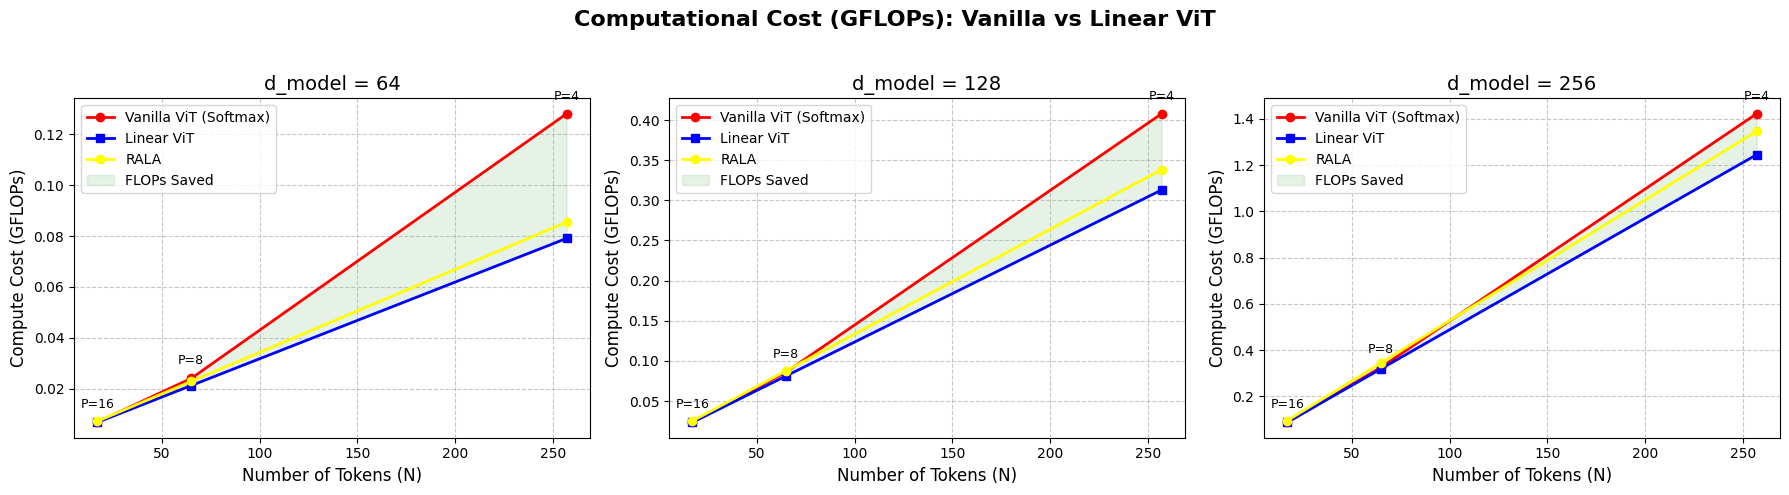

In [85]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.flop_counter import FlopCounterMode
from typing import Union, Tuple

# Ensure get_flops is defined
def get_flops(model, inp: Union[torch.Tensor, Tuple], with_backward=False):
    istrain = model.training
    model.eval()
    inp = inp if isinstance(inp, torch.Tensor) else torch.randn(inp)
    flop_counter = FlopCounterMode(mods=model, display=False, depth=None)
    with flop_counter:
        if with_backward:
            model(inp).sum().backward()
        else:
            model(inp)
    total_flops = flop_counter.get_total_flops()
    if istrain:
        model.train()
    return total_flops

# Define the hyperparameters to test
patch_sizes = [16, 8, 4]
d_models = [64, 128, 256]
img_size = 64

# Setup plots: 1 row, 3 columns (one for each d_model)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle("Computational Cost (GFLOPs): Vanilla vs Linear ViT", fontsize=16, fontweight='bold')

for idx, d_model in enumerate(d_models):
    vanilla_gflops = []
    linear_gflops = []
    RALA_gflops = []
    num_tokens_list = []
    
    for p in patch_sizes:
        # Calculate number of patches (N)
        num_tokens = (img_size // p)**2 + 1 # +1 for CLS token
        num_tokens_list.append(num_tokens)
        
        # 1. Instantiate and measure Vanilla ViT (attention_kind=1)
        model_vanilla = ViT(d_model=d_model, patch_size=p, attention_kind=1)
        flops_vanilla = get_flops(model_vanilla, (1, 3, img_size, img_size))
        vanilla_gflops.append(flops_vanilla / 1e9) # Convert to GFLOPs
        
        # 2. Instantiate and measure Linear ViT (attention_kind=0)
        model_linear = ViT(d_model=d_model, patch_size=p, attention_kind=0)
        flops_linear = get_flops(model_linear, (1, 3, img_size, img_size))
        linear_gflops.append(flops_linear / 1e9) # Convert to GFLOPs
        #
        model_RALA = ViT(d_model=d_model, patch_size=p, attention_kind=2)
        flops_RALA = get_flops(model_RALA, (1, 3, img_size, img_size))
        RALA_gflops.append(flops_RALA / 1e9) # Convert to GFLOPs
    # Plotting for this specific d_model
    ax = axes[idx]
    
    # We plot against Number of Tokens (N) to show the quadratic vs linear curve clearly
    ax.plot(num_tokens_list, vanilla_gflops, marker='o', color='red', linewidth=2, label='Vanilla ViT (Softmax)')
    ax.plot(num_tokens_list, linear_gflops, marker='s', color='blue', linewidth=2, label='Linear ViT')
    ax.plot(num_tokens_list, RALA_gflops,marker='o', color='yellow', linewidth=2, label='RALA')
    # Fill the area between the curves to highlight the FLOP savings
    ax.fill_between(num_tokens_list, linear_gflops, vanilla_gflops, color='green', alpha=0.1, label='FLOPs Saved')
    
    ax.set_title(f"d_model = {d_model}", fontsize=14)
    ax.set_xlabel("Number of Tokens (N)", fontsize=12)
    ax.set_ylabel("Compute Cost (GFLOPs)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc="upper left")
    
    # Annotate the patch sizes on the x-axis for context
    for i, txt in enumerate(patch_sizes):
        ax.annotate(f"P={txt}", (num_tokens_list[i], vanilla_gflops[i]), 
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout so suptitle fits
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os 
from tqdm import tqdm # Adds real-time progress bars!
attention_type = 1
checkpoint_dir = f'{attention_type}/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

best_acc = 0.0
# 1. Safer device routing (falls back to CPU if CUDA fails)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViT(attention_kind=attention_type).to(device)
optimizer = optim.AdamW(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

epochs = 1000
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

for epoch in range(epochs):
    # ==========================
    #       TRAINING PHASE
    # ==========================
    model.train()
    train_losses = []
    correct_train = 0
    total_train = 0
    
    # Wrap dataloader in tqdm for a clean console progress bar
    train_loop = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    step= 0
    for inputs, labels in train_loop:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        if epoch == 0 and step == 0:
          plot_grad_flow(model.named_parameters())
        optimizer.step()
        scheduler.step()
        step +=1 
        # Track metrics
        train_losses.append(loss.item())
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
        # Update the progress bar in real-time
        train_loop.set_postfix(loss=np.mean(train_losses), acc=100. * correct_train / total_train)
        
    # ==========================
    #      EVALUATION PHASE
    # ==========================
    if (epoch + 1) % 5 == 0:
        model.eval()
        val_losses = []
        correct_val = 0
        total_val = 0
        
        # THE FIX: Disable gradient calculation to save memory and speed up testing
        with torch.no_grad(): 
            val_loop = tqdm(test_dataloader, desc=f"Epoch {epoch+1}/{epochs} [Valid]")
            
            for inputs, labels in val_loop:
                inputs, labels = inputs.to(device), labels.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                # Track metrics
                val_losses.append(loss.item())
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                
                # Update the progress bar in real-time
                val_loop.set_postfix(loss=np.mean(val_losses), acc=100. * correct_val / total_val)
        val_acc = 100. * correct_val / total_val 
        # Print a clean summary at the end of the evaluation epoch
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_acc': best_acc,
        }

        # 1. Save the latest state
        torch.save(checkpoint, os.path.join(checkpoint_dir, 'latest_checkpoint.pth'))

        # 2. Save "Best" model if accuracy improved
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(checkpoint, os.path.join(checkpoint_dir, 'best_model.pth'))
            print(f"--> New Best Accuracy: {best_acc:.2f}%! Model Saved.")
        print(f"\n>>> SUMMARY Epoch {epoch+1} | Train Loss: {np.mean(train_losses):.4f} | Val Loss: {np.mean(val_losses):.4f} | Val Acc: {100. * correct_val / total_val:.2f}%\n")

In [ ]:
import torch
import os
import torchsummary
# Make sure your model is on the correct device before loading weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViT(attention_kind=1).to(device)
# Choose which checkpoint to load: 'best_model.pth' or 'latest_checkpoint.pth'
checkpoint_path = '1/checkpoints/latest_checkpoint.pth' 

if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}...")
    
    # Load the dictionary from the file
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # 1. Restore the model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # 2. Restore the optimizer's momentum and velocity 
    # (Crucial if you are going to resume training!)
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # 3. Restore your tracking variables
    start_epoch = checkpoint['epoch']
    best_acc = checkpoint['best_acc']
    
    print(f"Successfully loaded! Model is currently at Epoch {start_epoch} with a Best Validation Accuracy of {best_acc:.2f}%")
else:
    print(f"Error: Could not find the file at {checkpoint_path}.")
torchsummary.summary(model,(3,64,64))

Visualizing True Label: rose (Class 70)


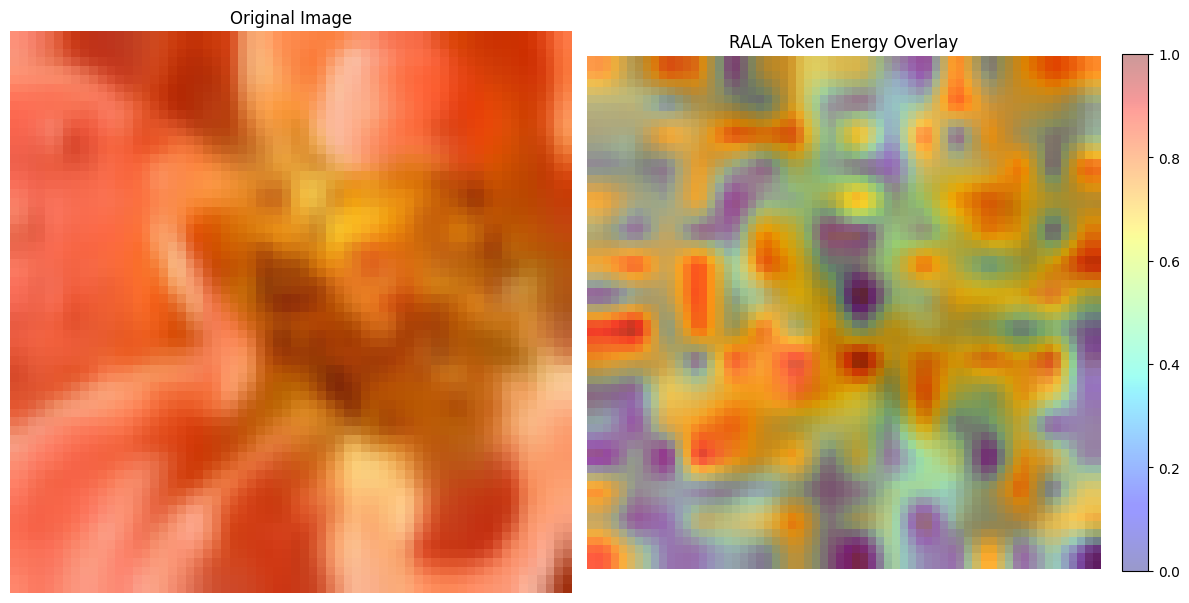

In [91]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np

def visualize_heatmap_overlay(model, img_tensor):
    model.eval()
    with torch.no_grad():
        # 1. Intercept the tokens before the head
        tokens = model.get_intermediate_tokens(img_tensor) 
        
    # 2. Remove the CLS token and calculate Energy
    spatial_tokens = tokens[0, 1:, :] 
    token_energy = torch.norm(spatial_tokens, p=2, dim=-1) 
    
    # 3. Get dimensions
    patch_size = model.patch_embedding.patch_size
    img_size = model.h
    grid_size = img_size // patch_size
    
    # 4. Reshape energy into a 2D spatial grid -> (1, 1, H, W) for PyTorch interpolation
    energy_grid = token_energy.reshape(1, 1, grid_size, grid_size)
    
    # 5. Smoothly upsample the grid to match the original image size (e.g., 64x64)
    energy_upsampled = F.interpolate(
        energy_grid, 
        size=(img_size, img_size), 
        mode='bilinear', 
        align_corners=False
    ).squeeze().cpu().numpy()
    
    # Normalize the upsampled energy map to [0, 1] for clean colormap rendering
    energy_upsampled = (energy_upsampled - energy_upsampled.min()) / (energy_upsampled.max() - energy_upsampled.min())
    
    # 6. Prepare the original image for plotting
    vis_img = img_tensor[0].permute(1, 2, 0).cpu().numpy()
    vis_img = (vis_img - vis_img.min()) / (vis_img.max() - vis_img.min())
    
    # 7. Plotting the Overlay Side by Side
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # --- Left Plot: Original Image ---
    axes[0].imshow(vis_img)
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    
    # --- Right Plot: Image + Heatmap Overlay ---
    axes[1].imshow(vis_img)
    # Draw the heatmap on top using a transparency channel (alpha)
    overlay = axes[1].imshow(energy_upsampled, cmap='jet', alpha=0.4) 
    axes[1].set_title("RALA Token Energy Overlay")
    axes[1].axis('off')
    
    # Add colorbar connected to the right plot
    fig.colorbar(overlay, ax=axes[1], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# Extract a sample and Run
# ==========================================
dataiter = iter(test_dataloader)
images, labels = next(dataiter)

sample_image = images[0]
sample_label = labels[0]
class_name = test_dataset.classes[sample_label.item()]

print(f"Visualizing True Label: {class_name} (Class {sample_label.item()})")

# Ensure model is on GPU and input has batch dimension
model = model.to(device)
model_input = sample_image.unsqueeze(0).to(device)

visualize_heatmap_overlay(model, model_input)